<a href="https://colab.research.google.com/github/SushmithaP2004/Data_science/blob/main/food_delivery_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab  import files
u=files.upload()

Saving Food_Delivery_Times.csv to Food_Delivery_Times.csv


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [13]:
df=pd.read_csv('Food_Delivery_Times.csv')
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [14]:
#data inspection
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [16]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [18]:
df[['Weather','Traffic_Level','Time_of_Day','Courier_Experience_yrs']]=df[['Weather','Traffic_Level','Time_of_Day','Courier_Experience_yrs']].ffill()
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [19]:
a=df.columns
print(a)

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')


In [21]:
for i in a:
  print(f"column names:{i}")
  print("unique values")
  print(df[i].unique())
  print("value counts")
  print(df[i].value_counts())
  print("================================")

column names:Order_ID
unique values
[ 522  738  741  661  412  679  627  514  860  137  812   77  637  974
  939  900  281  884  762  320  550  175  372  528  211  236  102  987
  903  948  347  140  622  500  371  199  688  585  902   60  329   97
  313  975  300  278  925  602  440  838  571  880  262  579   24   31
  618   11  222  821  297   55  543  210  605  693  663  867   71  544
  108  494  591  742  293  290  653   40  590  308  680   67  276   68
  319  549  999  715  754  328  383  452  523  219  788  437  765   89
   64  827  717  352  937  257  636  645  555  960  169  918  529  824
  986  817   87  433  185  979  535  295  893  426  714  261  238  560
  584  446  868  801  600  850  266  996  530   56  121  216   26   73
   45  248  722  282  894  915  811  245  823  322  644  159  978  430
  942  463  310  698   61  885  596  768  650  651  866  669  299  690
  315  311  362  480  111  990  487  364  255  260  803  678  495  671
  378  527  846  138  356  366  943  750 

In [23]:
df.dtypes

,0
Order_ID,int64
Distance_km,float64
Weather,object
Traffic_Level,object
Time_of_Day,object
Vehicle_Type,object
Preparation_Time_min,int64
Courier_Experience_yrs,float64
Delivery_Time_min,int64


In [24]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [25]:
print("minimum delivery time:",df['Delivery_Time_min'].min())
print("maximum delivery time:",df['Delivery_Time_min'].max())
#min and max distance
print("minimum distance",df['Distance_km' ].min())
print("maximum distance",df['Distance_km' ].max())


minimum delivery time: 8
maximum delivery time: 153
minimum distance 0.59
maximum distance 19.99


In [26]:
#min and max preperation time
print("minimum preperation time",df['Preparation_Time_min'].min())
print("maximum preperation time",df['Preparation_Time_min'].max())
#min and max courier experience years
print("minimum courier experience time",df['Courier_Experience_yrs'].min())
print("maximum courier experience time",df['Courier_Experience_yrs'].max())



minimum preperation time 5
maximum preperation time 29
minimum courier experience time 0.0
maximum courier experience time 9.0


Weather
Clear    481
Rainy    215
Foggy    105
Snowy    100
Windy     99
Name: count, dtype: int64


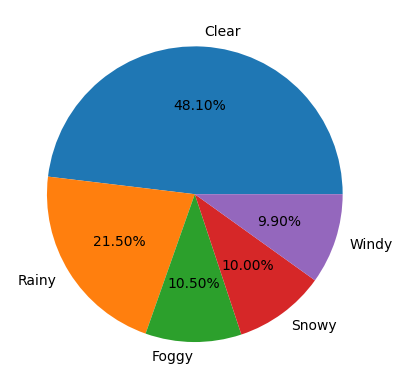

In [31]:
#visualizations
weather=df['Weather'].value_counts()
print(weather)
x=weather.index
y=weather.values
plt.pie(y,labels=x,autopct="%1.2f%%")
plt.show()

Time_of_Day
Morning      317
Evening      303
Afternoon    292
Night         88
Name: count, dtype: int64


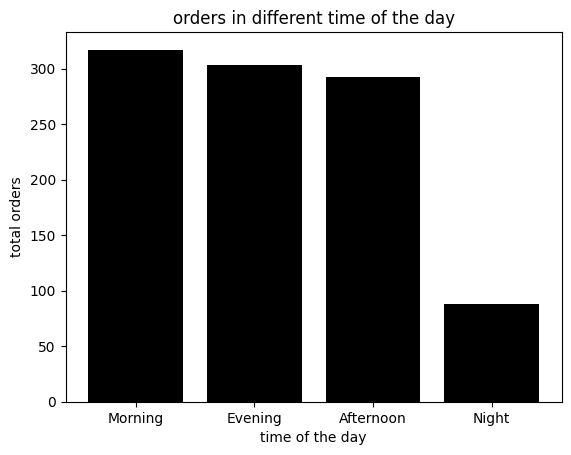

In [33]:
#orders in different time of the day
time=df['Time_of_Day'].value_counts()
print(time)
x=time.index
y=time.values
plt.bar(x,y,color='black')
plt.title('orders in different time of the day')
plt.xlabel('time of the day')
plt.ylabel('total orders')
plt.show()

In [44]:
from numpy._core import numeric
#correlation of delivery time column with others
numeric_df=df.select_dtypes(include=['number','float64'])
corr_values=numeric_df.corr()['Delivery_Time_min'].sort_values(ascending=True)
print(corr_values)

Weather_Clear            -0.166675
Traffic_Level            -0.108565
Courier_Experience_yrs   -0.090289
Order_ID                 -0.036650
Vehicle_Type_Scooter     -0.020444
Time_of_Day_Afternoon    -0.017422
Weather_Windy            -0.012517
Time_of_Day_Night        -0.012388
Time_of_Day_Morning      -0.009844
Vehicle_Type_Bike        -0.007180
Vehicle_Type_Car          0.032752
Time_of_Day_Evening       0.034841
Weather_Foggy             0.041130
Weather_Rainy             0.075543
Weather_Snowy             0.144576
Preparation_Time_min      0.307350
Distance_km               0.780998
Delivery_Time_min         1.000000
Name: Delivery_Time_min, dtype: float64


In [48]:
#dummy encoding
# dummy encoding
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Clean column names
df.columns = df.columns.str.strip()

# Encode ordinal column
lb = LabelEncoder()
df['Traffic_Level'] = lb.fit_transform(df['Traffic_Level'])



# Check result
print(df.head())
print(df.columns)

   Order_ID  Distance_km  Traffic_Level  Preparation_Time_min  \
0       522         7.93              1                    12   
1       738        16.42              2                    20   
2       741         9.52              1                    28   
3       661         7.44              2                     5   
4       412        19.03              1                    16   

   Courier_Experience_yrs  Delivery_Time_min  Weather_Clear  Weather_Foggy  \
0                     1.0                 43              0              0   
1                     2.0                 84              1              0   
2                     1.0                 59              0              1   
3                     1.0                 37              0              0   
4                     5.0                 68              1              0   

   Weather_Rainy  Weather_Snowy  Weather_Windy  Time_of_Day_Afternoon  \
0              0              0              1                     

In [49]:
#labelling data
x=df.drop('Delivery_Time_min',axis=1)
y=df['Delivery_Time_min']

In [50]:
print(x.columns)

Index(['Order_ID', 'Distance_km', 'Traffic_Level', 'Preparation_Time_min',
       'Courier_Experience_yrs', 'Weather_Clear', 'Weather_Foggy',
       'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy',
       'Time_of_Day_Afternoon', 'Time_of_Day_Evening', 'Time_of_Day_Morning',
       'Time_of_Day_Night', 'Vehicle_Type_Bike', 'Vehicle_Type_Car',
       'Vehicle_Type_Scooter'],
      dtype='object')


In [51]:
#splitting data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [53]:
print(x_train.shape)
print(y_test.shape)

(800, 17)
(200,)
